INFO  : Global CATMAID instance set. Caching is ON. (pymaid)
INFO  : Get all neurons with >= 2 nodes (pymaid)


Make nrn:   0%|          | 0/2014 [00:00<?, ?it/s]

INFO  : Found 2014 neurons matching the search parameters (pymaid)
100%|██████████| 2014/2014 [02:20<00:00, 14.35it/s]


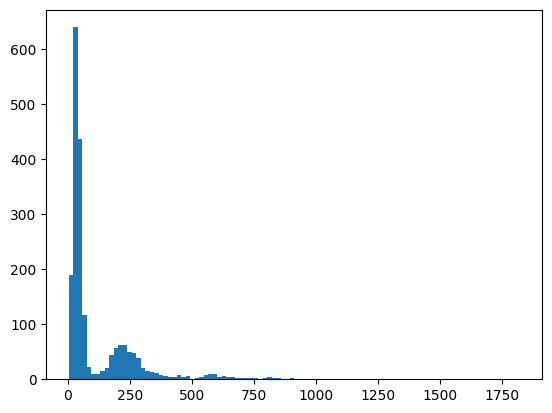

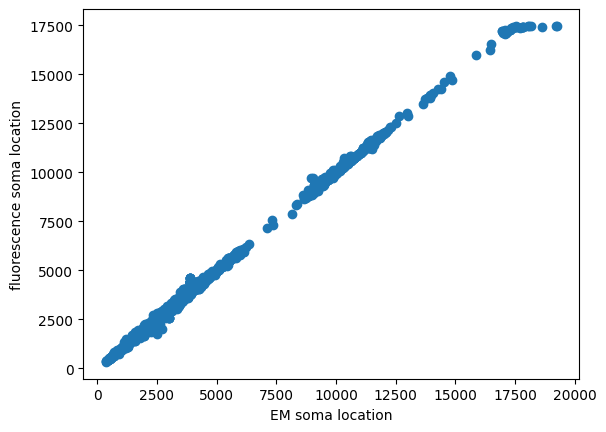

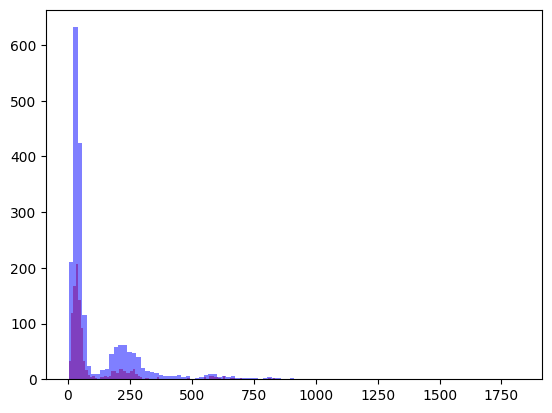

In [ ]:
import matplotlib.colors as mcolors
from scipy.cluster.hierarchy import fcluster, linkage, cut_tree, dendrogram, leaves_list
import plotly.express as px
import plotly.graph_objects as go
from scipy.spatial import cKDTree
import pymaid
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import navis

import os
base_path = os.path.expanduser("~/Downloads/")



rm = pymaid.CatmaidInstance(
    server="https://neurophyla.mrc-lmb.cam.ac.uk/catmaid/fibsem/",
    api_token='',
    http_user='',
    http_password='',
    project_id=
    
    # api_token='your_token',
    # http_user='your_username',
    # http_password='your_password',
)

ns = pymaid.find_neurons(min_size=2) #finds neurons

xs = []
ys = []
zs = []
skids = []
for n in tqdm(ns):
    if n.soma is not None:
        soma_id = int(np.atleast_1d(n.soma)[0])  # always safe regardless of array size
        soma = n.nodes[n.nodes.node_id == soma_id]
    else:
        soma = n.nodes[n.nodes.parent_id == -1]

    if len(soma) == 0:
        continue

    xs.append(soma.x.values[0])
    ys.append(soma.y.values[0])
    zs.append(soma.z.values[0])
    skids.append(n.id)




    # print(xs)
    # break
    # xs.append(soma.x)
    # ys.append(soma.y)
    # zs.append(soma.z)

soma_locs = pd.DataFrame({"x": xs, "y": ys, "z": zs, "skid": skids}) #puts into data frame
soma_locs["x_raw"] = soma_locs.x / 12
soma_locs["y_raw"] = soma_locs.y / 12
soma_locs["z_raw"] = soma_locs.z / 12

# read fluorescence data Michael generated
fluo_nofilter = np.load(f"{base_path}fluorescence_values_raw.npy")
 #loads raw fluorescence values

fluo = np.load(f"{base_path}smallROIFluorescence_values_raw_5x5x1.npy")


# 'C:\\Users\\44745\\Downloads\\fluorescence_values_wthfilt_25.npy')
# z, x, y, fluorescence - correction: should be z, y, x, fluorescence

# need to multiply the coordinates in fluo by 32
fluo[:, 1] = fluo[:, 1] * 32
fluo[:, 2] = fluo[:, 2] * 32
fluo[:, 0] = fluo[:, 0] * 32
fluo_nofilter[:, 1] = fluo_nofilter[:, 1] * 32
fluo_nofilter[:, 2] = fluo_nofilter[:, 2] * 32
fluo_nofilter[:, 0] = fluo_nofilter[:, 0] * 32


# find the closest fluorescence soma for each EM soma ---- kdtree method 
tree = cKDTree(fluo[:, [2, 1, 0]])

d, idx = tree.query(soma_locs[["x_raw", "y_raw", "z_raw"]]) 
soma_locs["closest_fluo_idx"] = idx
soma_locs["closest_fluo_dist"] = d
soma_locs["fluorescence"] = fluo[idx, 3]
soma_locs["fluo_x"] = fluo[idx, 2]
soma_locs["fluo_y"] = fluo[idx, 1]
soma_locs["fluo_z"] = fluo[idx, 0]

# histogram of closest distance ----
plt.hist(soma_locs.closest_fluo_dist, bins=100)
plt.show()
# inspect some somas
a = soma_locs[soma_locs.closest_fluo_dist > 600][["x", "y", "z"]].round(0)
set(map(tuple, a.values))

# check the correspondence in one axis ----
plt.scatter(soma_locs.z_raw, soma_locs.fluo_z)
plt.xlabel("EM soma location")
plt.ylabel("fluorescence soma location")
plt.show()

# are there many EM somas mapped onto the same fluorescence soma? ----
soma_locs.closest_fluo_idx.value_counts()
soma_locs_subset = soma_locs[soma_locs.closest_fluo_idx == 842]
# plot
trace1 = go.Scatter3d(
    x=soma_locs_subset.x_raw,
    y=soma_locs_subset.y_raw,
    z=soma_locs_subset.z_raw,
    mode="markers",
    hoverinfo="text",
    marker=dict(
        color=soma_locs_subset["fluorescence"],
        # colorscale = px.colors.qualitative.Plotly,
        size=5,
    ),
)
trace2 = go.Scatter3d(
    x=soma_locs.x_raw,
    y=soma_locs.y_raw,
    z=soma_locs.z_raw,
    mode="markers",
    # hoverinfo='text',
    marker=dict(
        color=soma_locs["fluorescence"],
        # colorscale = px.colors.qualitative.Plotly,
        opacity=0.2,
    ),
)
fig = go.Figure(data=[trace1, trace2])
fig.update_layout(width=1500, height=800)
fig.show()

# 3D interactive plot
# all soma locations ----
fig = px.scatter_3d(soma_locs, x="x_raw", y="y_raw", z="z_raw", color="fluorescence")
fig.show()

# 3D, plot all points in fluo ----
fig = px.scatter_3d(x=fluo[:, 2], y=fluo[:, 1], z=fluo[:, 0], color=fluo[:, 3])
# make points a bit smaller
fig.update_traces(marker=dict(size=3))
fig.show()

# plot both together ----
trace1 = go.Scatter3d(
    x=fluo[:, 2],
    y=fluo[:, 1],
    z=fluo[:, 0],
    mode="markers",
    hoverinfo="text",
    marker=dict(
        color=fluo[:, 3],
        # colorscale = px.colors.qualitative.Plotly,
        size=5,
    ),
)
trace2 = go.Scatter3d(
    x=soma_locs.x_raw,
    y=soma_locs.y_raw,
    z=soma_locs.z_raw,
    mode="markers",
    # hoverinfo='text',
    marker=dict(
        color="pink",
        # colorscale = px.colors.qualitative.Plotly,
        opacity=0.2,
    ),
)
fig = go.Figure(data=[trace1, trace2])
fig.update_layout(width=1500, height=800)
fig.show()

# soma locations and ones mapped ----
trace1 = go.Scatter3d(
    x=soma_locs.fluo_x,
    y=soma_locs.fluo_y,
    z=soma_locs.fluo_z,
    mode="markers",
    hoverinfo="text",
    marker=dict(
        color=soma_locs.fluorescence,
        # colorscale = px.colors.qualitative.Plotly,
        size=5,
    ),
)
trace2 = go.Scatter3d(
    x=soma_locs.x_raw,
    y=soma_locs.y_raw,
    z=soma_locs.z_raw,
    mode="markers",
    # hoverinfo='text',
    marker=dict(
        color="pink",
        # colorscale = px.colors.qualitative.Plotly,
        opacity=0.2,
    ),
)
fig = go.Figure(data=[trace1, trace2])
fig.update_layout(width=1500, height=800)
fig.show()

# filter fluo based on fig, to get ones in one hemisphere that need tracing
# y<6200, x<6000, z<6000
fluo_filtered = pd.DataFrame(
    fluo[(fluo[:, 0] < 6000) & (fluo[:, 1] < 6200) & (fluo[:, 2] < 6000)],
    columns=["fluo_z", "fluo_y", "fluo_x", "fluorescence"],
)

fig = px.scatter_3d(
    fluo_filtered, x="fluo_x", y="fluo_y", z="fluo_z", color="fluorescence"
)
fig.show()


trace1 = go.Scatter3d(
    x=fluo_filtered.fluo_x,
    y=fluo_filtered.fluo_y,
    z=fluo_filtered.fluo_z,
    mode="markers",
    hoverinfo="text",
    marker=dict(
        color=fluo_filtered["fluorescence"],
        # colorscale = px.colors.qualitative.Plotly,
        size=5,
    ),
)
trace2 = go.Scatter3d(
    x=soma_locs.x_raw,
    y=soma_locs.y_raw,
    z=soma_locs.z_raw,
    mode="markers",
    # hoverinfo='text',
    marker=dict(
        color=soma_locs["fluorescence"],
        # colorscale = px.colors.qualitative.Plotly,
        opacity=0.2,
    ),
)
fig = go.Figure(data=[trace1, trace2])
fig.update_layout(width=1500, height=800)
fig.show()

# put together: traced somas and the fluorescence of the closest segmented soma;
# and segmented somas from light in the selected hemisphere (by filtering above)
out = pd.merge(
    fluo_filtered,
    soma_locs,
    how="outer",
    on=["fluo_z", "fluo_x", "fluo_y", "fluorescence"],
)
out = out.round(0)

# also need to filter the traced somas to only contain the right hemisphere
# y<6200, x<6000, z<6000
out_right_cb = out[
    ((out.y_raw < 6200) & (out.x_raw < 6000) & (out.z_raw < 6000)) | out.x_raw.isna()
]

# visual inspection ----
trace1 = go.Scatter3d(
    x=fluo_filtered.fluo_x,
    y=fluo_filtered.fluo_y,
    z=fluo_filtered.fluo_z,
    mode="markers",
    hoverinfo="text",
    marker=dict(
        color=fluo_filtered["fluorescence"],
        # colorscale = px.colors.qualitative.Plotly,
        size=5,
    ),
)
trace2 = go.Scatter3d(
    x=out_right_cb.x_raw,
    y=out_right_cb.y_raw,
    z=out_right_cb.z_raw,
    mode="markers",
    # hoverinfo='text',
    marker=dict(
        color=out_right_cb["fluorescence"],
        # colorscale = px.colors.qualitative.Plotly,
        opacity=0.2,
    ),
)
fig = go.Figure(data=[trace1, trace2])
fig.update_layout(width=1500, height=800)
fig.show()

# visual inspection ----
plt.hist(out_right_cb.closest_fluo_dist, bins=100, color="r", alpha=0.5)
plt.hist(out.closest_fluo_dist, bins=100, color="b", alpha=0.5)
plt.show()

out["fluo_x_nm"] = out.fluo_x * 12
out["fluo_y_nm"] = out.fluo_y * 12
out["fluo_z_nm"] = out.fluo_z * 12
out_right_cb.to_csv(f"{base_path}fluorescence_spreadsheet.csv", index=False)
soma_locs.to_csv(f"{base_path}soma_locs.csv", index=False)




In [3]:
print (smallROIFluorescence_values_raw_5x5x1.npy)

NameError: name 'smallROIFluorescence_values_raw_5x5x1' is not defined